# White Blood Cell Count EDA
This notebook compares wbc labs (`itemid` = 51300) of patients with kidney disease to wbc labs of non-kidney patients. White blood cell count is a good measure of just how acutely sick the patients are and so it's another comparison between the 'extent of illness' of the kidney and non-kidney patients. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

We begin by extracting the wbc labs for patients with kidney disease. This is accomplished in the next two cells. 

In [2]:
kidney_disease_data = pd.read_csv('../Data/trimmed_kidney_disease_random_1000_patients.csv.gz',
                                 compression = 'gzip')
kidney_disease_data.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,268992,10015860,22413744.0,1702357,50853,NaN,2191-01-27 06:25:00,2191-01-28 13:25:00,___,11.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
1,1388766,10097612,NaN,97048763,50853,P19GXG,2159-05-17 12:35:00,2159-05-18 10:31:00,___,16.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
2,1952705,10132512,NaN,72063012,50853,P30YWU,2178-02-12 08:16:00,2178-02-13 09:42:00,___,32.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
3,1952726,10132512,NaN,77832825,50853,P30YWU,2178-05-16 07:55:00,2178-05-18 08:13:00,___,42.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
4,1952831,10132512,NaN,30613615,50853,P84CA4,2179-03-09 14:36:00,2179-03-10 13:31:00,___,33.0,ng/mL,30.0,60.0,NaN,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...


In [3]:
wbc_id = 51300
wbc_labs = kidney_disease_data.loc[kidney_disease_data['itemid'] == wbc_id]
kidney_disease_ids = list(set(wbc_labs['subject_id']))
wbc_labs_kidney_disease = pd.DataFrame(columns = ['wbc'])
for patient in kidney_disease_ids:
    earliest_lab_date = wbc_labs.loc[wbc_labs['subject_id'] == patient, 'charttime'].min()
    wbc_labs_kidney_disease.loc[patient] = wbc_labs.loc[(wbc_labs['subject_id'] == patient) & (wbc_labs['charttime'] == earliest_lab_date), 'valuenum'].values
wbc_labs_kidney_disease.head()

,wbc
17835008,5.6
17246092,6.3
15952397,4.3
16033805,5.0
10209298,6.3


Next, we repeat the procedure used above for patients with healthly kidneys. This is the content of the two cells that follow.

In [4]:
non_kidney_data = pd.read_csv('../Data/trimmed_normal_kidney_patients.csv.gz',
                                compression = 'gzip')
non_kidney_data.head()

,labevent_id,subject_id,hadm_id,specimen_id,itemid,order_provider_id,charttime,storetime,value,valuenum,valueuom,ref_range_lower,ref_range_upper,flag,priority,comments
0,656869,10041351,28202624.0,87960306,50853,NaN,2117-09-24 06:24:00,2117-09-26 14:57:00,20,20.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NaN
1,206675,10012703,NaN,65289690,50853,P134DE,2184-02-27 13:45:00,2184-02-28 10:30:00,___,4.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
2,206771,10012703,NaN,45239687,50853,P134DE,2184-06-05 10:30:00,2184-06-08 10:45:00,___,24.0,ng/mL,30.0,60.0,abnormal,STAT,NEW ASSAY IN USE ___: DETECTS D2 AND D3 25-OH ...
3,680714,10043423,NaN,40263589,50853,P941BA,2140-07-04 15:15:00,2140-07-06 15:11:00,8,8.0,ng/mL,30.0,60.0,abnormal,ROUTINE,NaN
4,255932,10014790,NaN,89220377,50853,P61084,2171-10-26 14:35:00,2171-10-26 19:17:00,___,46.0,ng/mL,30.0,60.0,NaN,ROUTINE,"Effective ___, values will be reported from th..."


In [9]:
wbc_labs_ver2 = non_kidney_data.loc[non_kidney_data['itemid'] == wbc_id]
non_kidney_ids = list(set(wbc_labs_ver2['subject_id']))
wbc_non_kidney = pd.DataFrame(columns = ['wbc'])
for patient in non_kidney_ids:
    earliest_lab_date = wbc_labs_ver2.loc[wbc_labs_ver2['subject_id'] == patient, 'charttime'].min()
    wbc_non_kidney.loc[patient] = wbc_labs_ver2.loc[(wbc_labs_ver2['subject_id'] == patient) & (wbc_labs_ver2['charttime'] == earliest_lab_date), 'valuenum'].values
wbc_non_kidney.head()

,wbc
10010848,6.2
10038119,4.2
10058123,5.8
10013419,3.0
10032651,6.9


To conclude this notebook, we use the wbc lab readings to create a histogram for both groups of patients. We also calculate the number of patients in each group with a wbc lab reading. This information is output after the histogram.  

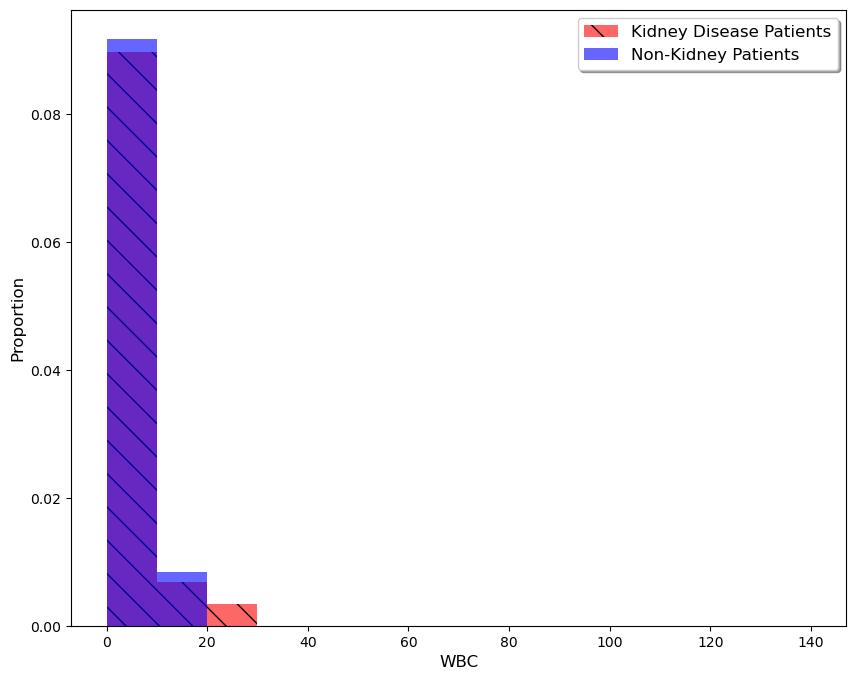

The number of kidney patients that have a wbc lab reading is 29 

The number of non-kidney patients that have a wbc lab reading is 12


In [10]:
plt.figure(figsize = (10, 8))
plt.hist(wbc_labs_kidney_disease['wbc'],
        color = 'red',
        hatch = '\\',
        alpha = 0.6,
        density = True,
        bins = np.arange(0, 150, 10),
        label = 'Kidney Disease Patients')
plt.hist(wbc_non_kidney['wbc'],
        color = 'blue',
        alpha = 0.6,
        density = True,
        bins = np.arange(0, 150, 10),
        label = 'Non-Kidney Patients')
plt.xlabel('WBC', 
          fontsize = 12)
plt.ylabel('Proportion',
          fontsize = 12)
plt.legend(fontsize = 12,
          loc = 'upper right',
          fancybox = True,
          shadow = True)
plt.show()
print('The number of kidney patients that have a wbc lab reading is', wbc_labs_kidney_disease.shape[0], '\n')
print('The number of non-kidney patients that have a wbc lab reading is', wbc_non_kidney.shape[0])